# İstanbul Raylı Sistemler 2025 - Analiz

In [28]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

os.makedirs("figures", exist_ok=True)

yolcu = pd.read_csv("passenger_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["date"])
sefer = pd.read_csv("trips_clean.csv", sep=";", encoding="utf-8-sig", parse_dates=["Tarih"])

yas_sirasi = ["<20", "20-30", "30-60", "60+", "Bilinmiyor"]
yolcu["age"] = pd.Categorical(yolcu["age"], categories=yas_sirasi, ordered=True)

print(yolcu.shape, sefer.shape)

(678010, 13) (1489, 5)


In [29]:
ANA_RENK = "#3b6ea5"
VURGU_RENK = "#c2185b"
KAYNAK = "İBB Açık Veri Portalı"

TUR_RENK = {
    "Metro": "#3b6ea5",
    "Tramvay": "#e08a3c",
    "Füniküler": "#5a9e6f",
    "Teleferik": "#8c6bb1",
    "Banliyö (TCDD)": "#8c564b",
}

def hat_turu(kod):
    if kod == "Marmaray" or kod.startswith("TCDD"):
        return "Banliyö (TCDD)"
    if kod == "IETT TUNEL":
        return "Füniküler"
    if kod == "IETT NOSTALJIK TRAMVAY":
        return "Tramvay"
    if kod.startswith("TF"):
        return "Teleferik"
    if kod.startswith("M"):
        return "Metro"
    if kod.startswith("T"):
        return "Tramvay"
    return "Füniküler"

def baslik_ekle(ax, baslik, altbaslik=None):
    ax.set_title(baslik, loc="left", fontsize=12, fontweight="bold", pad=22 if altbaslik else 10)
    if altbaslik:
        ax.text(0, 1.02, altbaslik, transform=ax.transAxes, fontsize=9, color="gray", va="bottom")

def footer_ekle(fig, donem, birim, not_metni=None):
    satir = f"Kaynak: {KAYNAK} | Dönem: {donem} | Birim: {birim}"
    if not_metni:
        satir = not_metni + "\n" + satir
    fig.text(0.01, 0.01, satir, fontsize=7, color="gray", va="bottom")

## 0. Geçiş ve yolcu sayısı

In [30]:
print("Geçişin yolcudan az olduğu satır sayısı:", (yolcu["passage_cnt"] < yolcu["passanger_cnt"]).sum())

gecis_orani = yolcu.groupby("line_code")[["passage_cnt", "passanger_cnt"]].sum()
gecis_orani = (gecis_orani["passage_cnt"] / gecis_orani["passanger_cnt"]).sort_values()
print(gecis_orani.round(2))

yas_gecis = yolcu.groupby("age", observed=True)[["passage_cnt", "passanger_cnt"]].sum()
print((yas_gecis["passage_cnt"] / yas_gecis["passanger_cnt"]).round(2))

Geçişin yolcudan az olduğu satır sayısı: 0
line_code
TCDD - HALKALI-BASAKSEHIR    1.02
M8                           1.03
M6                           1.03
M5                           1.04
M7                           1.04
M3                           1.05
M4                           1.05
Marmaray                     1.05
M9                           1.05
F4                           1.05
T4                           1.06
M2                           1.06
M1                           1.07
TCDD SIRKECI-KAZLICESME      1.08
M11                          1.09
T5                           1.10
T1                           1.14
IETT TUNEL                   1.22
T3                           1.23
F1                           1.25
TF1                          1.37
IETT NOSTALJIK TRAMVAY       1.58
TF2                          1.93
dtype: float64
age
<20           1.05
20-30         1.04
30-60         1.05
60+           1.17
Bilinmiyor    1.05
dtype: float64


Gezi hatlarında ve 60+ grubunda geçiş/yolcu oranı yüksek. Analizde `passanger_cnt` kullanıldı.

## 1. Hat bazında yolcu

In [31]:
hat_yolcu = yolcu.groupby("line_code")["passanger_cnt"].sum().sort_values(ascending=False)
print(hat_yolcu)

line_code
Marmaray                     211013465
M2                           144902910
T1                           107480340
M5                           105871816
M1                           104618911
M4                           102313233
M7                            75396747
T4                            57056314
M3                            49897239
M8                            24864688
M9                            24472718
T5                            20318350
M11                           10812046
M6                             5372638
F1                             3964775
TCDD SIRKECI-KAZLICESME        3897893
IETT TUNEL                     2697027
F4                             1229968
T3                              952863
TF2                             844905
IETT NOSTALJIK TRAMVAY          386438
TF1                             221489
TCDD - HALKALI-BASAKSEHIR       112429
Name: passanger_cnt, dtype: int64


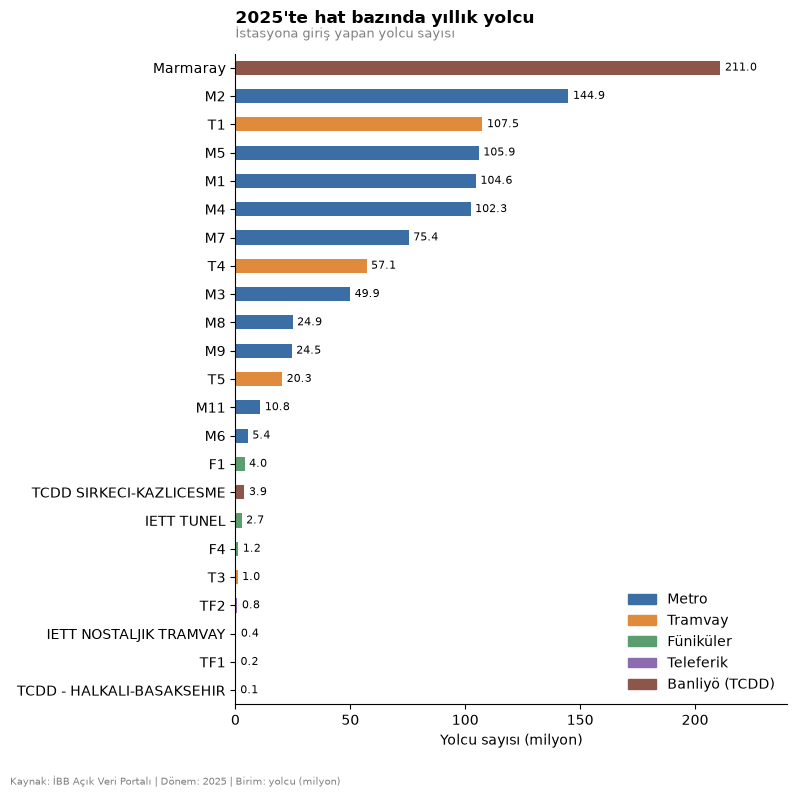

In [32]:
veri = (hat_yolcu / 1_000_000).sort_values()
renkler = [TUR_RENK[hat_turu(kod)] for kod in veri.index]
turler = sorted({hat_turu(kod) for kod in veri.index}, key=list(TUR_RENK).index)

fig, ax = plt.subplots(figsize=(8, 8))
veri.plot(kind="barh", ax=ax, color=renkler)

for i, deger in enumerate(veri):
    ax.text(deger + 2, i, f"{deger:.1f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color=TUR_RENK[tur], label=tur) for tur in turler], loc="lower right", frameon=False)
baslik_ekle(ax, "2025'te hat bazında yıllık yolcu", "İstasyona giriş yapan yolcu sayısı")
ax.set_xlabel("Yolcu sayısı (milyon)")
ax.set_ylabel("")
ax.set_xlim(0, 240)

footer_ekle(fig, "2025", "yolcu (milyon)")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figures/hat_bazli_yolcu.png", dpi=150)
plt.show()

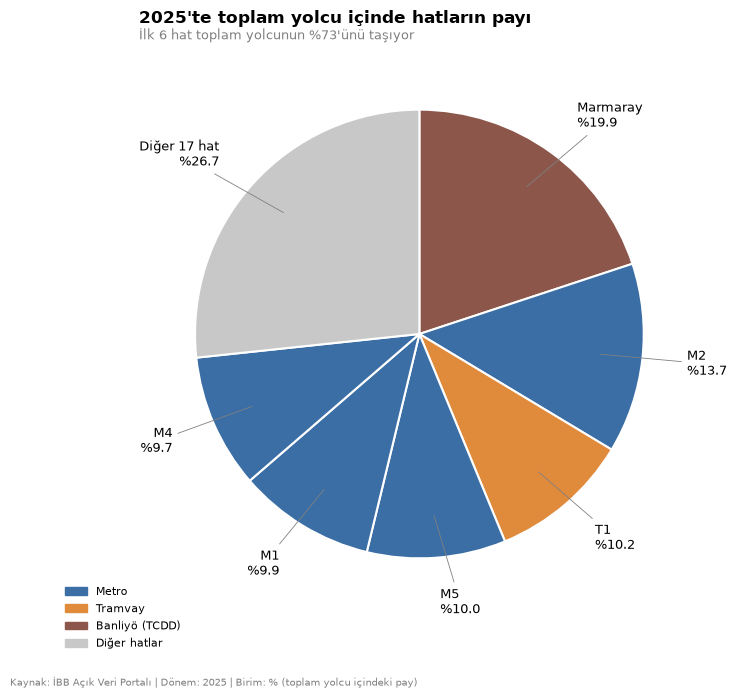

In [33]:
pay = hat_yolcu / hat_yolcu.sum() * 100
ilk = pay.sort_values(ascending=False).head(6)
diger = pay.drop(ilk.index)
pasta = pd.concat([ilk, pd.Series({f"Diğer {len(diger)} hat": diger.sum()})])

renkler = [TUR_RENK[hat_turu(kod)] for kod in ilk.index] + ["#c8c8c8"]
turler = sorted({hat_turu(kod) for kod in ilk.index}, key=list(TUR_RENK).index)

fig, ax = plt.subplots(figsize=(8, 7))
dilimler, yazilar = ax.pie(pasta.values, colors=renkler, startangle=90, counterclock=False,
                           wedgeprops={"edgecolor": "white", "linewidth": 1.5})

for dilim, ad, deger in zip(dilimler, pasta.index, pasta.values):
    aci = np.deg2rad((dilim.theta1 + dilim.theta2) / 2)
    x, y = np.cos(aci), np.sin(aci)
    ax.annotate(f"{ad}\n%{deger:.1f}", xy=(0.8 * x, 0.8 * y), xytext=(1.2 * x, 1.2 * y),
                ha="left" if x > 0 else "right", va="center", fontsize=9,
                arrowprops={"arrowstyle": "-", "color": "gray", "linewidth": 0.6})

ax.set_aspect("equal")
ax.legend(handles=[Patch(color=TUR_RENK[tur], label=tur) for tur in turler] + [Patch(color="#c8c8c8", label="Diğer hatlar")],
          loc="lower left", bbox_to_anchor=(-0.15, -0.08), frameon=False, fontsize=8)
baslik_ekle(ax, "2025'te toplam yolcu içinde hatların payı",
            f"İlk 6 hat toplam yolcunun %{ilk.sum():.0f}'ünü taşıyor")

footer_ekle(fig, "2025", "% (toplam yolcu içindeki pay)")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figures/hat_paylari.png", dpi=150)
plt.show()

### En yoğun 10 istasyon

347 giriş adı -> 295 hat-istasyon
line_code  istasyon    
Marmaray   Yenikapı        26.9
           Üsküdar         23.3
M2         Yenikapı        23.3
           Şişli           22.7
M5         Üsküdar         18.4
M1         Yenikapı        17.1
M7         Mecidiyeköy     15.2
Marmaray   Sirkeci         14.7
M2         Osmanbey        14.4
Marmaray   Ayrılıkçeşme    12.7
Name: passanger_cnt, dtype: float64


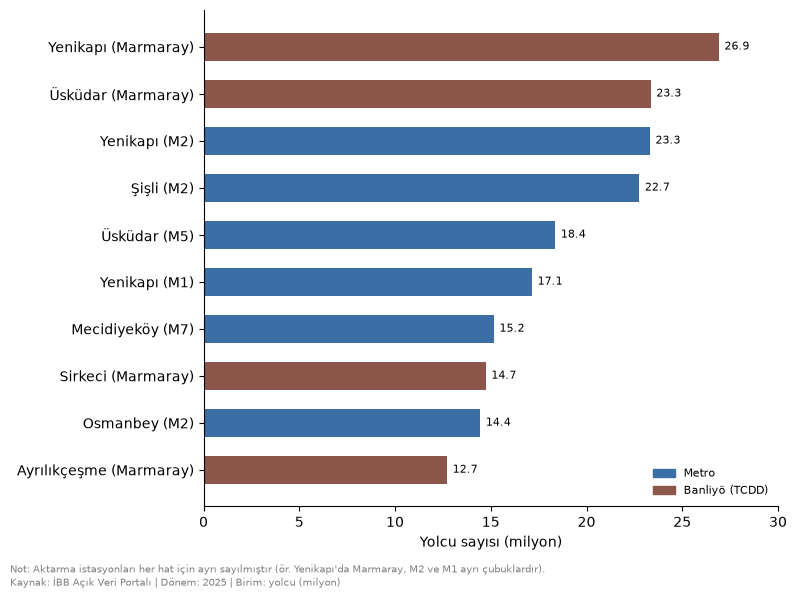

In [34]:
import re

def tr_kucuk(metin):
    return metin.replace("I", "ı").replace("İ", "i").lower()

def tr_baslik(metin):
    kelimeler = []
    for k in metin.split():
        ilk = {"i": "İ", "ı": "I"}.get(k[0], k[0].upper())
        kelimeler.append(ilk + k[1:])
    return " ".join(kelimeler)

def istasyon_adi(ad):
    ad = tr_kucuk(ad)
    ad = re.sub(r"\(.*?\)", " ", ad)
    ad = re.sub(r"\b(m\d+|hol|konkors)\b", " ", ad)
    ad = re.sub(r"\b(kuzey|güney|guney|doğu|dogu|batı|bati)\b", " ", ad)
    ad = re.sub(r"-\s*\d+$", " ", ad)
    ad = re.sub(r"(?<=\D)\s\d+(\s|$)", " ", ad)
    ad = re.sub(r"\s+", " ", ad).strip()
    ad = {"ayrılıkçeşmesi": "ayrılıkçeşme", "özgürlük meydan": "özgürlük meydanı"}.get(ad, ad)
    return tr_baslik(ad).replace("İtü", "İTÜ")

yolcu["istasyon"] = yolcu["station_name"].map(istasyon_adi)
print(yolcu["station_name"].nunique(), "giriş adı ->", yolcu.groupby(["line_code", "istasyon"]).ngroups, "hat-istasyon")

istasyon_yolcu = yolcu.groupby(["line_code", "istasyon"])["passanger_cnt"].sum().sort_values(ascending=False)
ilk10 = istasyon_yolcu.head(10) / 1_000_000
print(ilk10.round(1))

veri = ilk10.iloc[::-1]
etiketler = [f"{ist} ({hat})" for hat, ist in veri.index]
renkler = [TUR_RENK[hat_turu(hat)] for hat, ist in veri.index]
turler = sorted({hat_turu(hat) for hat, ist in veri.index}, key=list(TUR_RENK).index)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(etiketler, veri.values, color=renkler, height=0.6)

for i, deger in enumerate(veri.values):
    ax.text(deger + 0.3, i, f"{deger:.1f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color=TUR_RENK[tur], label=tur) for tur in turler], loc="lower right", frameon=False, fontsize=8)
ax.set_xlabel("Yolcu sayısı (milyon)")
ax.set_xlim(0, 30)

footer_ekle(fig, "2025", "yolcu (milyon)",
            "Not: Aktarma istasyonları her hat için ayrı sayılmıştır (ör. Yenikapı'da Marmaray, M2 ve M1 ayrı çubuklardır).")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/en_yogun_istasyonlar.png", dpi=150)
plt.show()

Yenikapı ve Üsküdar iki ayrı hatla birden listede. Osmanbey dışındaki istasyonların hepsi başka bir raylı hatta aktarma noktası.

Marmaray açık ara birinci; ilk altı hat toplam yolcunun yaklaşık %73'ünü taşıyor.

## 2. Sefer başına yolcu

In [35]:
aylik_yolcu = (
    yolcu.groupby(["line_code", "transaction_year", "transaction_month"])["passanger_cnt"]
    .sum()
    .reset_index()
    .rename(columns={"transaction_year": "year", "transaction_month": "month"})
)

print(aylik_yolcu.head())
print(aylik_yolcu.shape)

  line_code  year  month  passanger_cnt
0        F1  2025      1         333829
1        F1  2025      2         275118
2        F1  2025      3         239630
3        F1  2025      4         322788
4        F1  2025      5         357300
(276, 4)


In [36]:
sefer_2025 = sefer[sefer["year"] == 2025]
print(sefer_2025.shape)

(204, 5)


In [37]:
birlesik = aylik_yolcu.merge(
    sefer_2025[["line_code", "year", "month", "sefer_sayisi"]],
    on=["line_code", "year", "month"],
    how="left"
)

print(birlesik[birlesik["sefer_sayisi"].isna()]["line_code"].unique())

<StringArray>
[   'IETT NOSTALJIK TRAMVAY',                'IETT TUNEL',
                       'M11',                  'Marmaray',
 'TCDD - HALKALI-BASAKSEHIR',   'TCDD SIRKECI-KAZLICESME']
Length: 6, dtype: str


In [38]:
birlesik = birlesik.dropna(subset=["sefer_sayisi"])

hat_oran = birlesik.groupby("line_code")[["passanger_cnt", "sefer_sayisi"]].sum()
hat_oran["sefer_basina_yolcu"] = hat_oran["passanger_cnt"] / hat_oran["sefer_sayisi"]
hat_oran = hat_oran.sort_values("sefer_basina_yolcu", ascending=False)

print(hat_oran.round(0))

           passanger_cnt  sefer_sayisi  sefer_basina_yolcu
line_code                                                 
M5             105871816      130864.0               809.0
M4             102313233      136202.0               751.0
M2             144902910      227721.0               636.0
M3              49897239       91869.0               543.0
M1             104618911      213478.0               490.0
T4              57056314      135550.0               421.0
M7              75396747      187814.0               401.0
T1             107480340      276281.0               389.0
M8              24864688       81973.0               303.0
M9              24472718       81330.0               301.0
T5              20318350       83417.0               244.0
M6               5372638       90863.0                59.0
T3                952863       25894.0                37.0
F1               3964775      117009.0                34.0
F4               1229968       98656.0                12

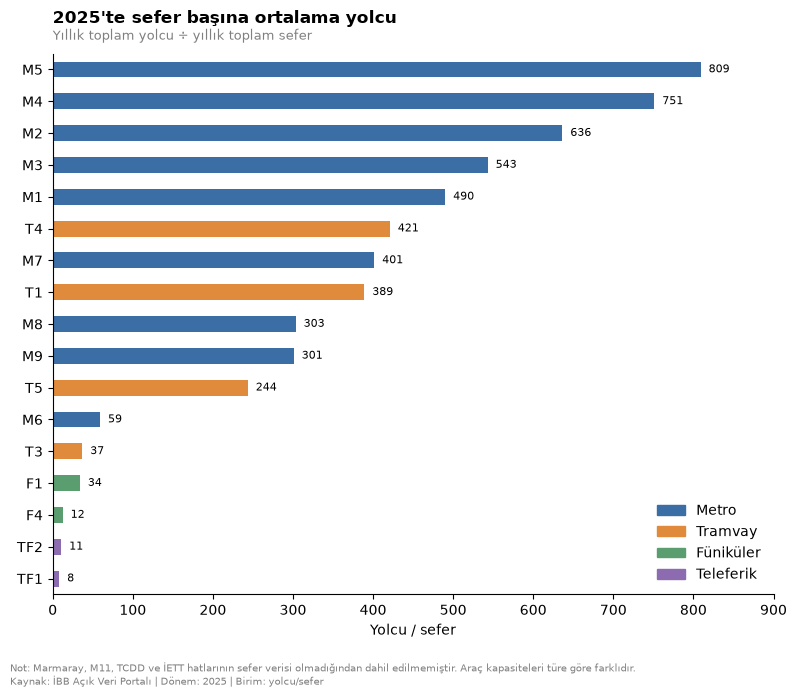

In [39]:
veri = hat_oran["sefer_basina_yolcu"].sort_values()

renkler = [TUR_RENK[hat_turu(kod)] for kod in veri.index]
turler = sorted({hat_turu(kod) for kod in veri.index}, key=list(TUR_RENK).index)

fig, ax = plt.subplots(figsize=(8, 7))
veri.plot(kind="barh", ax=ax, color=renkler)

for i, deger in enumerate(veri):
    ax.text(deger + 10, i, f"{deger:.0f}", va="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
ax.legend(handles=[Patch(color=TUR_RENK[tur], label=tur) for tur in turler], loc="lower right", frameon=False)
baslik_ekle(ax, "2025'te sefer başına ortalama yolcu", "Yıllık toplam yolcu ÷ yıllık toplam sefer")
ax.set_xlabel("Yolcu / sefer")
ax.set_ylabel("")
ax.set_xlim(0, 900)

footer_ekle(fig, "2025", "yolcu/sefer",
            "Not: Marmaray, M11, TCDD ve İETT hatlarının sefer verisi olmadığından dahil edilmemiştir. Araç kapasiteleri türe göre farklıdır.")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("figures/sefer_basina_yolcu.png", dpi=150)
plt.show()

Toplamda 4. olan M5, sefer başına yolcuda birinci. T1 toplamda 3. ama çok sefer yaptığı için burada 8.

## 3. Aylık seyir

In [40]:
aylik_toplam = yolcu.groupby("transaction_month")["passanger_cnt"].sum()
gun_sayisi = yolcu.groupby("transaction_month")["date"].nunique()
gunluk_ort = aylik_toplam / gun_sayisi

print(pd.DataFrame({"toplam": aylik_toplam, "gun": gun_sayisi, "gunluk_ort": gunluk_ort.round(0)}))

                     toplam  gun  gunluk_ort
transaction_month                           
1                  90674343   31   2924979.0
2                  80305579   28   2868056.0
3                  90797668   31   2928957.0
4                  88153603   30   2938453.0
5                  96412578   31   3110083.0
6                  81429296   30   2714310.0
7                  78105677   31   2519538.0
8                  75518055   31   2436066.0
9                  85227049   30   2840902.0
10                 99009937   31   3193869.0
11                 94445793   30   3148193.0
12                 98619624   31   3181278.0


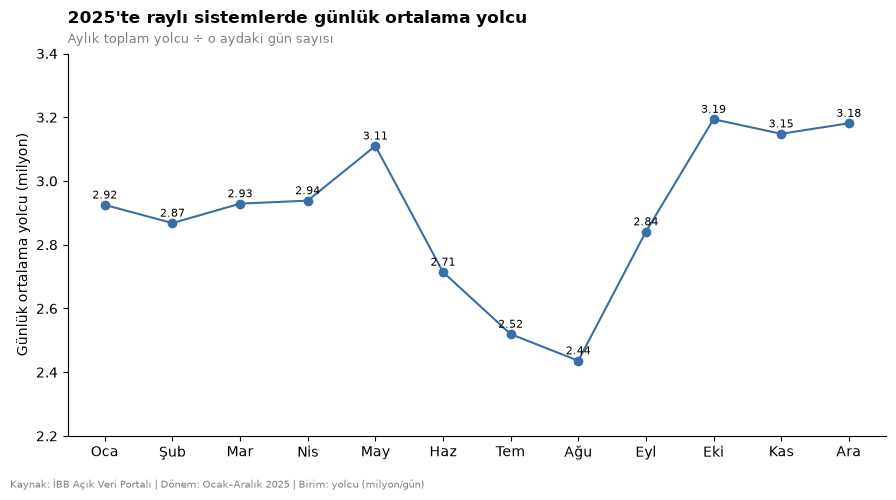

In [41]:
aylar = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]
veri = gunluk_ort / 1_000_000

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(aylar, veri, marker="o", color=ANA_RENK)

for ay, deger in zip(aylar, veri):
    ax.text(ay, deger + 0.02, f"{deger:.2f}", ha="center", fontsize=8)

ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te raylı sistemlerde günlük ortalama yolcu",
            "Aylık toplam yolcu ÷ o aydaki gün sayısı")
ax.set_ylabel("Günlük ortalama yolcu (milyon)")
ax.set_ylim(2.2, 3.4)

footer_ekle(fig, "Ocak–Aralık 2025", "yolcu (milyon/gün)")
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("figures/aylik_gunluk_ortalama.png", dpi=150)
plt.show()

Günlük ortalama Ağustos'ta en düşük (2,44 milyon), Ekim'de en yüksek (3,19 milyon).

## 4. Yaş dağılımı

In [42]:
yas_toplam = yolcu.groupby("age", observed=True)["passanger_cnt"].sum()
yas_pay = yas_toplam / yas_toplam.sum() * 100
print(yas_pay.round(1))

age
<20            9.3
20-30         26.4
30-60         35.0
60+           13.7
Bilinmiyor    15.5
Name: passanger_cnt, dtype: float64


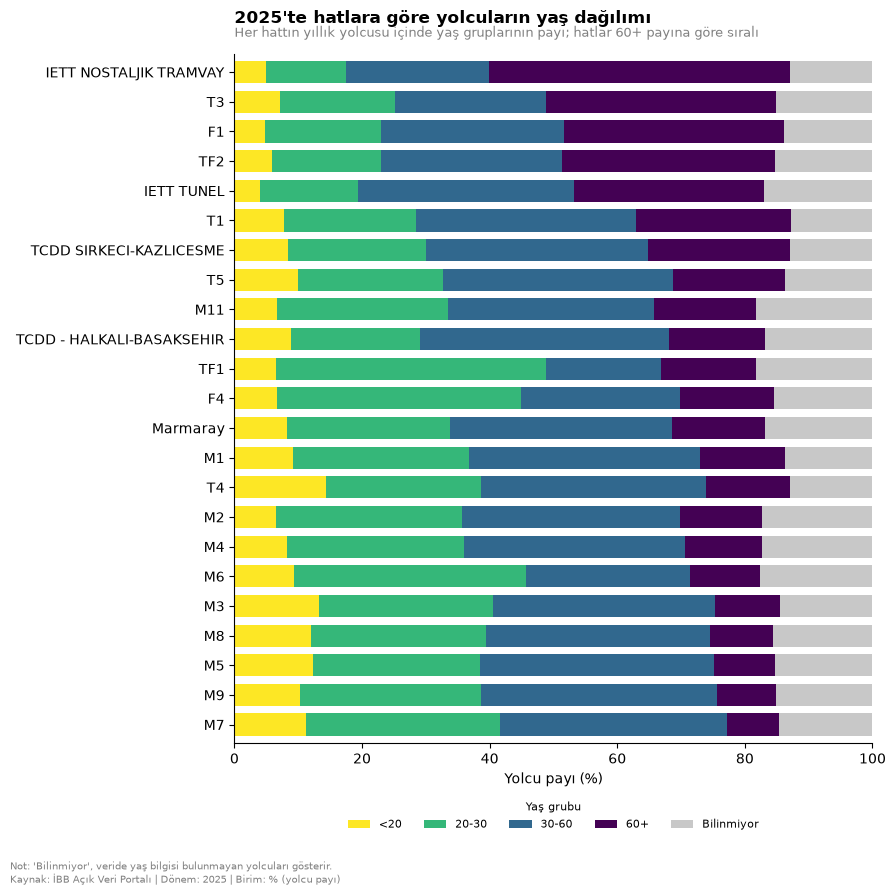

In [43]:
hat_yas = yolcu.pivot_table(index="line_code", columns="age", values="passanger_cnt",
                            aggfunc="sum", observed=True)
hat_yas = hat_yas.reindex(columns=yas_sirasi)
hat_yas_pay = hat_yas.div(hat_yas.sum(axis=1), axis=0) * 100
veri = hat_yas_pay.sort_values("60+")

yas_renk = ["#fde725", "#35b779", "#31688e", "#440154", "#c8c8c8"]


fig, ax = plt.subplots(figsize=(9, 9))
veri.plot(kind="barh", stacked=True, ax=ax, color=yas_renk, width=0.75)

ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te hatlara göre yolcuların yaş dağılımı",
            "Her hattın yıllık yolcusu içinde yaş gruplarının payı; hatlar 60+ payına göre sıralı")
ax.set_xlabel("Yolcu payı (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Yaş grubu", ncol=5, loc="upper center", bbox_to_anchor=(0.5, -0.07),
          frameon=False, fontsize=8, title_fontsize=8)

footer_ekle(fig, "2025", "% (yolcu payı)", "Not: 'Bilinmiyor', veride yaş bilgisi bulunmayan yolcuları gösterir.")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/hat_yas_dagilimi.png", dpi=150)
plt.show()

Nostaljik tramvayda yolcuların neredeyse yarısı 60 yaş üstü; büyük metrolarda bu oran %8-13.

## 5. Hafta sonu kullanımı

In [44]:
gunluk_hat = yolcu.groupby(["line_code", "date", "is_weekend"])["passanger_cnt"].sum().reset_index()
ort = gunluk_hat.groupby(["line_code", "is_weekend"])["passanger_cnt"].mean().unstack()
oran = (ort[True] / ort[False] * 100).sort_values()
print(oran.round(0))

line_code
TCDD - HALKALI-BASAKSEHIR     27.0
M8                            57.0
M2                            61.0
M6                            62.0
M7                            62.0
M9                            64.0
M3                            64.0
M4                            65.0
TCDD SIRKECI-KAZLICESME       67.0
T4                            68.0
T3                            69.0
M5                            69.0
T1                            71.0
M1                            76.0
F1                            78.0
Marmaray                      81.0
M11                           81.0
T5                            82.0
TF1                           90.0
IETT NOSTALJIK TRAMVAY        94.0
IETT TUNEL                    94.0
F4                            96.0
TF2                          110.0
dtype: float64


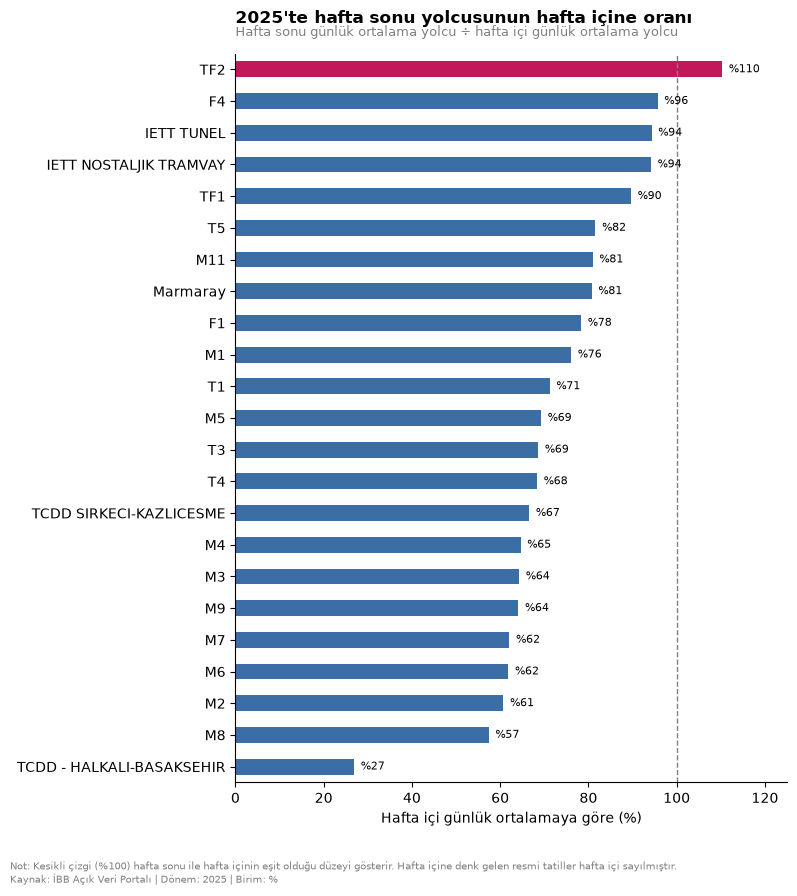

In [45]:
fig, ax = plt.subplots(figsize=(8, 9))
renkler = [VURGU_RENK if d > 100 else ANA_RENK for d in oran]
oran.plot(kind="barh", ax=ax, color=renkler)

for i, d in enumerate(oran):
    ax.text(d + 1.5, i, f"%{d:.0f}", va="center", fontsize=8)

ax.axvline(100, color="gray", linestyle="--", linewidth=1)
ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te hafta sonu yolcusunun hafta içine oranı",
            "Hafta sonu günlük ortalama yolcu ÷ hafta içi günlük ortalama yolcu")
ax.set_xlabel("Hafta içi günlük ortalamaya göre (%)")
ax.set_ylabel("")
ax.set_xlim(0, 125)

footer_ekle(fig, "2025", "%",
            "Not: Kesikli çizgi (%100) hafta sonu ile hafta içinin eşit olduğu düzeyi gösterir. Hafta içine denk gelen resmi tatiller hafta içi sayılmıştır.")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("figures/hafta_sonu_orani.png", dpi=150)
plt.show()

Metrolar hafta sonu hafta içinin %57-76'sına düşüyor; TF2 hafta sonu daha kalabalık.

## 6. Olağan dışı günler

In [46]:
gunluk = (yolcu.groupby("date")["passanger_cnt"].sum() / 1_000_000).rename("yolcu").to_frame()
gunluk["gun_adi"] = gunluk.index.day_name()

def referans_hesapla(seri, hafta=4):
    medyanlar, madlar, n_ler = [], [], []
    for tarih in seri.index:
        komsular = [tarih + pd.Timedelta(weeks=k) for k in range(-hafta, hafta + 1) if k != 0]
        degerler = seri.reindex(komsular).dropna()
        m = degerler.median()
        medyanlar.append(m)
        madlar.append((degerler - m).abs().median())
        n_ler.append(len(degerler))
    return (pd.Series(medyanlar, seri.index),
            pd.Series(madlar, seri.index),
            pd.Series(n_ler, seri.index))

gunluk["referans"], gunluk["mad"], gunluk["n_ref"] = referans_hesapla(gunluk["yolcu"])
gunluk["robust_z"] = 0.6745 * (gunluk["yolcu"] - gunluk["referans"]) / gunluk["mad"]
gunluk["sapma_yuzde"] = (gunluk["yolcu"] / gunluk["referans"] - 1) * 100
gunluk["anomali"] = (gunluk["robust_z"].abs() > 3.5) & (gunluk["sapma_yuzde"].abs() > 5)

anomaliler = gunluk[gunluk["anomali"]]
print(len(anomaliler), "anomali günü")
print(anomaliler[["gun_adi", "yolcu", "referans", "sapma_yuzde", "robust_z", "n_ref"]].round(2))

23 anomali günü
              gun_adi  yolcu  referans  sapma_yuzde  robust_z  n_ref
date                                                                
2025-01-01  Wednesday   2.20      3.17       -30.65    -11.94      4
2025-01-06     Monday   3.40      3.09         9.99      4.18      4
2025-01-07    Tuesday   3.45      3.14         9.85     81.62      4
2025-02-21     Friday   2.59      3.38       -23.55     -4.14      8
2025-03-29   Saturday   2.13      2.55       -16.36     -4.08      8
2025-03-31     Monday   2.52      3.38       -25.23     -5.54      8
2025-04-01    Tuesday   2.21      3.43       -35.60     -6.21      8
2025-04-02  Wednesday   2.33      3.37       -30.90    -11.71      8
2025-04-03   Thursday   2.67      3.37       -20.79     -3.68      8
2025-04-04     Friday   2.83      3.41       -17.14     -6.51      8
2025-04-19   Saturday   2.96      2.55        16.14      5.00      8
2025-04-23  Wednesday   2.36      3.44       -31.37     -8.96      8
2025-04-24   Thurs

In [47]:
aciklamalar = {
    "2025-01-01": ("Yılbaşı", "kesin"),
    "2025-01-06": ("Referans penceresi yarıyıl tatilini içeriyor", "yöntem etkisi"),
    "2025-01-07": ("Referans penceresi yarıyıl tatilini içeriyor", "yöntem etkisi"),
    "2025-02-21": ("Yoğun kar; okullar tatil", "kesin"),
    "2025-03-29": ("Ramazan Bayramı arifesi", "kesin"),
    "2025-03-31": ("Ramazan Bayramı", "kesin"),
    "2025-04-01": ("Ramazan Bayramı", "kesin"),
    "2025-04-02": ("Okulların 2. dönem ara tatili", "kesin"),
    "2025-04-03": ("Okulların 2. dönem ara tatili", "kesin"),
    "2025-04-04": ("Okulların 2. dönem ara tatili", "kesin"),
    "2025-04-19": ("AÖF ara sınavı; sınava girenlere ücretsiz ulaşım", "olası"),
    "2025-04-23": ("23 Nisan tatili + öğlen 6,2'lik deprem", "kesin"),
    "2025-04-24": ("Deprem sonrası okullar ve üniversiteler tatil", "kesin"),
    "2025-04-25": ("Deprem sonrası okullar ve üniversiteler tatil", "kesin"),
    "2025-05-01": ("1 Mayıs; Valilik kararıyla istasyon ve hat kapatmaları", "kesin"),
    "2025-06-06": ("Kurban Bayramı", "kesin"),
    "2025-06-09": ("Kurban Bayramı", "kesin"),
    "2025-10-28": ("Cumhuriyet Bayramı arifesi", "kesin"),
    "2025-10-29": ("Cumhuriyet Bayramı", "kesin"),
    "2025-11-11": ("Açıklanamadı", "açıklanamadı"),
    "2025-12-07": ("Açıklanamadı", "açıklanamadı"),
    "2025-12-28": ("Açıklanamadı (referans penceresi kısa)", "açıklanamadı"),
    "2025-12-31": ("Yılbaşı arifesi", "kesin"),
}

tablo = anomaliler[["gun_adi", "sapma_yuzde", "robust_z"]].copy()
tablo["aciklama"] = [aciklamalar.get(t.strftime("%Y-%m-%d"), ("?", "?"))[0] for t in tablo.index]
tablo["guven"] = [aciklamalar.get(t.strftime("%Y-%m-%d"), ("?", "?"))[1] for t in tablo.index]
print(tablo.round(1).to_string())
print()
print(tablo["guven"].value_counts())

              gun_adi  sapma_yuzde  robust_z                                                aciklama          guven
date                                                                                                               
2025-01-01  Wednesday        -30.7     -11.9                                                 Yılbaşı          kesin
2025-01-06     Monday         10.0       4.2            Referans penceresi yarıyıl tatilini içeriyor  yöntem etkisi
2025-01-07    Tuesday          9.8      81.6            Referans penceresi yarıyıl tatilini içeriyor  yöntem etkisi
2025-02-21     Friday        -23.5      -4.1                                Yoğun kar; okullar tatil          kesin
2025-03-29   Saturday        -16.4      -4.1                                 Ramazan Bayramı arifesi          kesin
2025-03-31     Monday        -25.2      -5.5                                         Ramazan Bayramı          kesin
2025-04-01    Tuesday        -35.6      -6.2                            

### Bilinen olaylarla kontrol

In [48]:
bilinen_olaylar = {
    "2025-01-01": "Yılbaşı (ücretsiz ulaşım)",
    "2025-01-18": "AÖF güz final sınavı",
    "2025-02-20": "Kar tatili",
    "2025-02-21": "Kar tatili",
    "2025-03-31": "Ramazan Bayramı",
    "2025-04-01": "Ramazan Bayramı",
    "2025-04-19": "AÖF bahar ara sınavı",
    "2025-04-23": "23 Nisan + deprem",
    "2025-04-24": "Deprem sonrası okul tatili",
    "2025-04-25": "Deprem sonrası okul tatili",
    "2025-05-01": "1 Mayıs + kapatmalar",
    "2025-05-19": "19 Mayıs (ücretsiz ulaşım)",
    "2025-06-05": "Kurban Bayramı arifesi",
    "2025-06-06": "Kurban Bayramı",
    "2025-06-09": "Kurban Bayramı",
    "2025-07-15": "15 Temmuz",
    "2025-10-06": "İstanbul'un Kurtuluşu (ücretsiz ulaşım)",
    "2025-10-29": "Cumhuriyet Bayramı",
}
dogrulama = gunluk.loc[pd.to_datetime(list(bilinen_olaylar)), ["gun_adi", "sapma_yuzde", "robust_z", "anomali"]].copy()
dogrulama.insert(1, "olay", list(bilinen_olaylar.values()))
print(dogrulama.round(1).to_string())
print(f"\nYakalanan: {dogrulama['anomali'].sum()} / {len(dogrulama)}")

              gun_adi                                     olay  sapma_yuzde  robust_z  anomali
2025-01-01  Wednesday                Yılbaşı (ücretsiz ulaşım)        -30.7     -11.9     True
2025-01-18   Saturday                     AÖF güz final sınavı         13.2       2.4    False
2025-02-20   Thursday                               Kar tatili        -21.2      -2.7    False
2025-02-21     Friday                               Kar tatili        -23.5      -4.1     True
2025-03-31     Monday                          Ramazan Bayramı        -25.2      -5.5     True
2025-04-01    Tuesday                          Ramazan Bayramı        -35.6      -6.2     True
2025-04-19   Saturday                     AÖF bahar ara sınavı         16.1       5.0     True
2025-04-23  Wednesday                        23 Nisan + deprem        -31.4      -9.0     True
2025-04-24   Thursday               Deprem sonrası okul tatili        -33.8      -6.6     True
2025-04-25     Friday               Deprem sonrası

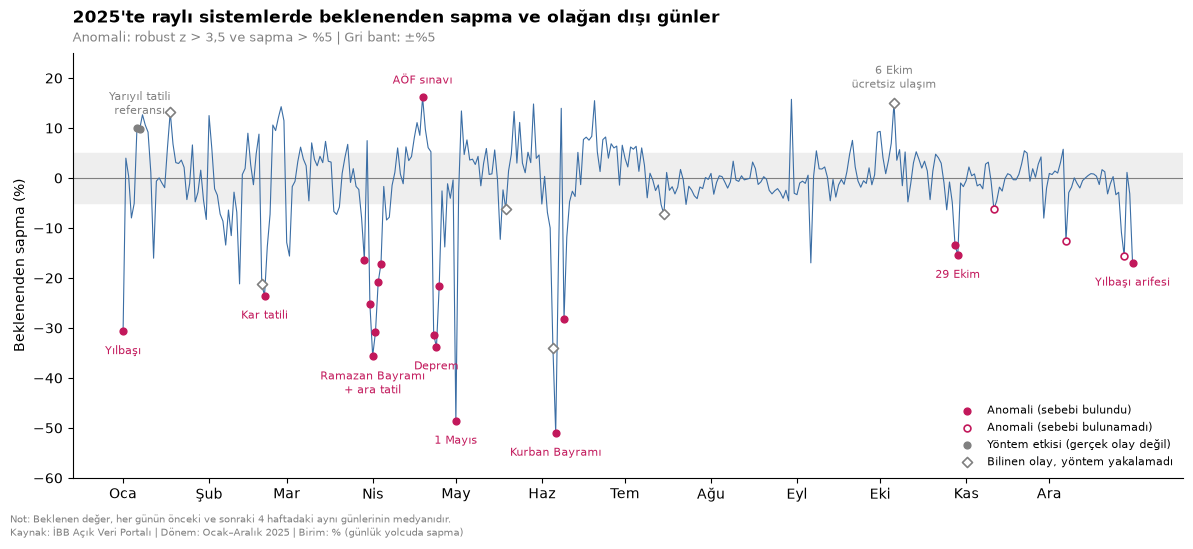

In [49]:
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.axhspan(-5, 5, color="#eeeeee", zorder=0)
ax.axhline(0, color="gray", linewidth=0.8)
ax.plot(gunluk.index, gunluk["sapma_yuzde"], color=ANA_RENK, linewidth=0.8)

aciklanan = tablo[tablo["guven"].isin(["kesin", "olası"])]
aciklanamayan = tablo[tablo["guven"] == "açıklanamadı"]
yontem = tablo[tablo["guven"] == "yöntem etkisi"]

ax.scatter(aciklanan.index, aciklanan["sapma_yuzde"], color=VURGU_RENK, s=24, zorder=3,
           label="Anomali (sebebi bulundu)")
ax.scatter(aciklanamayan.index, aciklanamayan["sapma_yuzde"], facecolors="white", edgecolors=VURGU_RENK,
           linewidths=1.2, s=24, zorder=3, label="Anomali (sebebi bulunamadı)")
ax.scatter(yontem.index, yontem["sapma_yuzde"], color="gray", s=24, zorder=3,
           label="Yöntem etkisi (gerçek olay değil)")

kacan = dogrulama[~dogrulama["anomali"]]
ax.scatter(kacan.index, kacan["sapma_yuzde"], marker="D", facecolors="white", edgecolors="gray",
           linewidths=1.2, s=26, zorder=3, label="Bilinen olay, yöntem yakalamadı")

etiketler = {
    "2025-01-01": "Yılbaşı",
    "2025-01-07": "Yarıyıl tatili\nreferansı",
    "2025-02-21": "Kar tatili",
    "2025-04-01": "Ramazan Bayramı\n+ ara tatil",
    "2025-04-19": "AÖF sınavı",
    "2025-04-24": "Deprem",
    "2025-05-01": "1 Mayıs",
    "2025-06-06": "Kurban Bayramı",
    "2025-10-06": "6 Ekim\nücretsiz ulaşım",
    "2025-10-29": "29 Ekim",
    "2025-12-31": "Yılbaşı arifesi",
}
for tarih, metin in etiketler.items():
    t = pd.Timestamp(tarih)
    y = gunluk.loc[t, "sapma_yuzde"]
    if t in yontem.index or t in kacan.index:
        renk = "gray"
    else:
        renk = VURGU_RENK
    ax.annotate(metin, (t, y), xytext=(0, 8 if y > 0 else -10), textcoords="offset points",
                ha="center", va="bottom" if y > 0 else "top", fontsize=8, color=renk)

ay_basi = pd.date_range("2025-01-01", "2025-12-01", freq="MS")
ax.set_xticks(ay_basi)
ax.set_xticklabels(["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"])
ax.set_ylim(-60, 25)
ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te raylı sistemlerde beklenenden sapma ve olağan dışı günler",
            "Anomali: robust z > 3,5 ve sapma > %5 | Gri bant: ±%5")
ax.set_ylabel("Beklenenden sapma (%)")
ax.legend(loc="lower right", frameon=False, fontsize=8)

footer_ekle(fig, "Ocak–Aralık 2025", "% (günlük yolcuda sapma)",
            "Not: Beklenen değer, her günün önceki ve sonraki 4 haftadaki aynı günlerinin medyanıdır.")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/anomali_gunluk.png", dpi=150)
plt.show()

18 olayın 12'si yakalandı.

### 1 Mayıs: istasyon bazında

In [50]:
istasyon_gunluk = yolcu.groupby(["line_code", "station_name", "date"])["passanger_cnt"].sum()

hedef = pd.Timestamp("2025-05-01")
ref_gunler = [hedef + pd.Timedelta(weeks=k) for k in range(-4, 5) if k != 0]

o_gun = istasyon_gunluk.xs(hedef, level="date")
referans = istasyon_gunluk[istasyon_gunluk.index.get_level_values("date").isin(ref_gunler)].groupby(level=[0, 1]).median()

mayis = pd.DataFrame({"1_mayis": o_gun, "referans": referans}).fillna(0)
mayis["degisim_yuzde"] = (mayis["1_mayis"] / mayis["referans"] - 1) * 100

kapananlar = mayis[(mayis["referans"] > 500) & (mayis["degisim_yuzde"] < -95)]
print(len(kapananlar), "istasyonda giriş neredeyse sıfır (>%95 düşüş)")
print(kapananlar.round(0).sort_values("referans", ascending=False).to_string())

45 istasyonda giriş neredeyse sıfır (>%95 düşüş)
                                                        1_mayis  referans  degisim_yuzde
line_code               station_name                                                    
M2                      Şişli 2 Kuzey                      79.0   60994.0         -100.0
M7                      MECİDİYEKÖY BATI                    0.0   47987.0         -100.0
M2                      Gayrettepe                       1263.0   37954.0          -97.0
                        Taksim Güney                       84.0   32564.0         -100.0
                        Osmanbey 2 Güney                   40.0   26032.0         -100.0
Marmaray                Sirkeci-1                         995.0   24671.0          -96.0
M2                      Osmanbey Kuzey                     23.0   24666.0         -100.0
T1                      Sirkeci                           869.0   18465.0          -95.0
                        Eminönü 2                         613

45 istasyonda giriş neredeyse sıfır; düşüşün çoğu kapatmalardan kaynaklanıyor.

## 7. 60+ oranı ve hafta sonu kullanımı

In [51]:
pay_60 = hat_yas["60+"] / hat_yas.sum(axis=1) * 100

iliski = pd.DataFrame({"pay_60": pay_60, "hafta_sonu": oran})
iliski["tur"] = [hat_turu(k) for k in iliski.index]

rho, p = stats.spearmanr(iliski["pay_60"], iliski["hafta_sonu"])

rng = np.random.default_rng(42)
x_sira, y_sira = iliski["pay_60"].rank().values, iliski["hafta_sonu"].rank().values
perm = np.array([np.corrcoef(x_sira, rng.permutation(y_sira))[0, 1] for _ in range(10_000)])
p_perm = (np.abs(perm) >= abs(rho)).mean()

boot = []
for _ in range(5_000):
    i = rng.integers(0, len(iliski), len(iliski))
    boot.append(stats.spearmanr(iliski["pay_60"].iloc[i], iliski["hafta_sonu"].iloc[i])[0])
alt, ust = np.nanpercentile(boot, [2.5, 97.5])

print(f"n = {len(iliski)} hat")
print(f"Spearman rho = {rho:.2f}, p = {p:.4f}, permütasyon p = {p_perm:.4f}")
print(f"%95 bootstrap güven aralığı: [{alt:.2f}, {ust:.2f}]")

toplam_yolcu = yolcu.groupby("line_code")["passanger_cnt"].sum()
buyuk = iliski[toplam_yolcu.reindex(iliski.index) > 1_000_000]
rho_b, p_b = stats.spearmanr(buyuk["pay_60"], buyuk["hafta_sonu"])
print(f"Duyarlılık (yılda 1 milyondan fazla yolcusu olan {len(buyuk)} hat): rho = {rho_b:.2f}, p = {p_b:.4f}")

n = 23 hat
Spearman rho = 0.62, p = 0.0017, permütasyon p = 0.0029
%95 bootstrap güven aralığı: [0.30, 0.82]
Duyarlılık (yılda 1 milyondan fazla yolcusu olan 18 hat): rho = 0.71, p = 0.0009


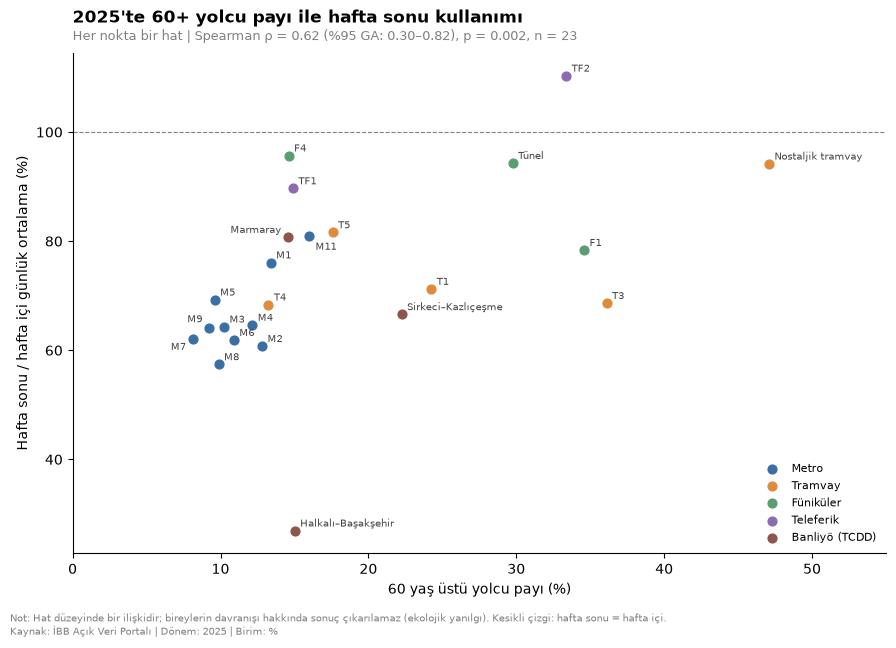

In [52]:
fig, ax = plt.subplots(figsize=(9, 6.5))
for tur, renk in TUR_RENK.items():
    grup = iliski[iliski["tur"] == tur]
    ax.scatter(grup["pay_60"], grup["hafta_sonu"], color=renk, s=40, label=tur, zorder=3)

ETIKET_KONUM = {
    "Marmaray": (-5, 3, "right"),
    "M11": (5, -10, "left"),
    "M7": (-5, -8, "right"),
    "M9": (-5, 4, "right"),
}

KISA_AD = {
    "IETT NOSTALJIK TRAMVAY": "Nostaljik tramvay",
    "IETT TUNEL": "Tünel",
    "TCDD SIRKECI-KAZLICESME": "Sirkeci–Kazlıçeşme",
    "TCDD - HALKALI-BASAKSEHIR": "Halkalı–Başakşehir",
}
for kod, satir in iliski.iterrows():
    dx, dy, hizalama = ETIKET_KONUM.get(kod, (4, 3, "left"))
    ax.annotate(KISA_AD.get(kod, kod),
                (satir["pay_60"], satir["hafta_sonu"]),
                xytext=(dx, dy), textcoords="offset points", ha=hizalama, fontsize=7, color="#444444")

ax.axhline(100, color="gray", linestyle="--", linewidth=0.8)
ax.spines[["top", "right"]].set_visible(False)
baslik_ekle(ax, "2025'te 60+ yolcu payı ile hafta sonu kullanımı",
            f"Her nokta bir hat | Spearman ρ = {rho:.2f} (%95 GA: {alt:.2f}–{ust:.2f}), p = {p:.3f}, n = {len(iliski)}")
ax.set_xlabel("60 yaş üstü yolcu payı (%)")
ax.set_ylabel("Hafta sonu / hafta içi günlük ortalama (%)")
ax.set_xlim(0, 55)
ax.legend(frameon=False, fontsize=8, loc="lower right")

footer_ekle(fig, "2025", "%",
            "Not: Hat düzeyinde bir ilişkidir; bireylerin davranışı hakkında sonuç çıkarılamaz (ekolojik yanılgı). Kesikli çizgi: hafta sonu = hafta içi.")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("figures/yas_hafta_sonu_iliskisi.png", dpi=150)
plt.show()

ρ = 0,62 (p = 0,002). Hat düzeyinde bir ilişki; bireysel davranış hakkında sonuç çıkarılamaz.

## 8. Kampüs hatları

TF1 {1: 110.0, 2: 81.0, 3: 130.0, 4: 113.0, 5: 140.0, 6: 91.0, 7: 62.0, 8: 62.0, 9: 69.0, 10: 118.0, 11: 124.0, 12: 99.0}
F4 {1: 86.0, 2: 81.0, 3: 107.0, 4: 101.0, 5: 118.0, 6: 102.0, 7: 97.0, 8: 80.0, 9: 90.0, 10: 120.0, 11: 115.0, 12: 102.0}
TF2 {1: 98.0, 2: 78.0, 3: 93.0, 4: 91.0, 5: 108.0, 6: 117.0, 7: 116.0, 8: 107.0, 9: 107.0, 10: 98.0, 11: 102.0, 12: 85.0}


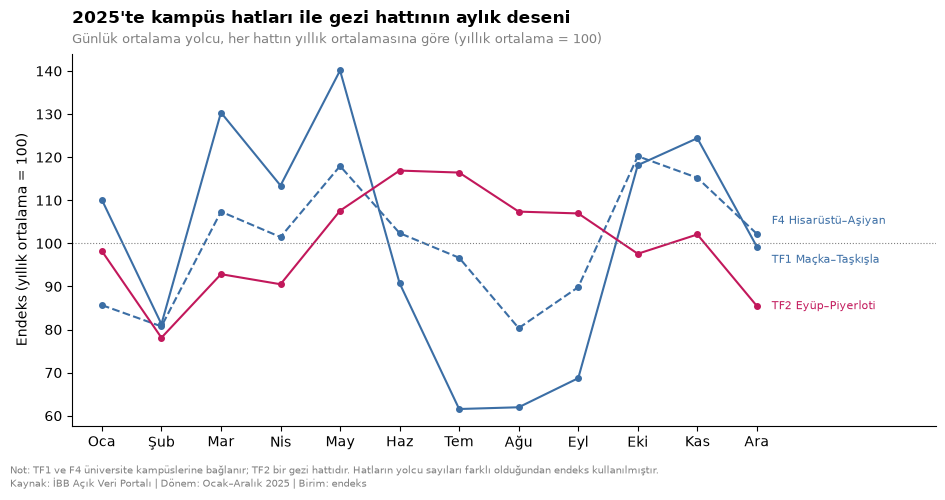

In [53]:
hat_gunluk = yolcu.groupby(["line_code", "date"])["passanger_cnt"].sum().unstack(0)
aylar = ["Oca", "Şub", "Mar", "Nis", "May", "Haz", "Tem", "Ağu", "Eyl", "Eki", "Kas", "Ara"]

stiller = {
    "TF1": {"color": ANA_RENK, "linestyle": "-", "etiket": "TF1 Maçka–Taşkışla", "dy": -3},
    "F4": {"color": ANA_RENK, "linestyle": "--", "etiket": "F4 Hisarüstü–Aşiyan", "dy": 3},
    "TF2": {"color": VURGU_RENK, "linestyle": "-", "etiket": "TF2 Eyüp–Piyerloti", "dy": 0},
}

fig, ax = plt.subplots(figsize=(9.5, 5))
for hat, stil in stiller.items():
    aylik = hat_gunluk[hat].groupby(hat_gunluk.index.month).mean()
    endeks = aylik / aylik.mean() * 100
    print(hat, endeks.round(0).to_dict())
    ax.plot(aylar, endeks.values, marker="o", markersize=4, color=stil["color"], linestyle=stil["linestyle"])
    ax.text(11.25, endeks.values[-1] + stil["dy"], stil["etiket"], va="center", fontsize=8, color=stil["color"])

ax.axhline(100, color="gray", linewidth=0.8, linestyle=":")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-0.5, 14)
baslik_ekle(ax, "2025'te kampüs hatları ile gezi hattının aylık deseni",
            "Günlük ortalama yolcu, her hattın yıllık ortalamasına göre (yıllık ortalama = 100)")
ax.set_ylabel("Endeks (yıllık ortalama = 100)")

footer_ekle(fig, "Ocak–Aralık 2025", "endeks",
            "Not: TF1 ve F4 üniversite kampüslerine bağlanır; TF2 bir gezi hattıdır. Hatların yolcu sayıları farklı olduğundan endeks kullanılmıştır.")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig("figures/kampus_gezi_hatlari.png", dpi=150)
plt.show()

In [54]:
print(hat_yas_pay["20-30"].sort_values(ascending=False).round(1).head(6))

for hat in ["M6", "M2", "M4"]:
    aylik = hat_gunluk[hat].groupby(hat_gunluk.index.month).mean()
    print(hat, (aylik / aylik.mean() * 100).round(0).astype(int).tolist())

line_code
TF1    42.4
F4     38.2
M6     36.3
M7     30.4
M2     29.2
M9     28.5
Name: 20-30, dtype: float64
M6 [91, 107, 112, 97, 113, 86, 79, 69, 93, 121, 115, 117]
M2 [105, 102, 101, 100, 106, 89, 83, 79, 94, 113, 111, 115]
M4 [103, 101, 102, 101, 107, 92, 84, 80, 98, 111, 109, 112]


TF1, F4 ve M6 yazın belirgin düşüyor ve 20-30 yaş oranı en yüksek üç hat.